# The research document for testing ideas


## Idea one time series forcasting of stock data
the attempt will be to forcast the price of an asset that is publicly traded for ease of access to data.


In [73]:
#imports
import torch
import yfinance as yf
import numpy as np
import pandas as pd
from transformers import TimesFm2_5ModelForPrediction
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [74]:
#Modal
model_id = "google/timesfm-2.5-200m-transformers"
model = TimesFm2_5ModelForPrediction.from_pretrained(model_id)
model = model.to(torch.float32).eval()

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3644.12it/s]


In [75]:
#Data
ticker = "NVDA"
data = yf.download(ticker, period="2y")
prices = data["Close"].dropna().values
# Normalize the data (recommended for Time Series models)
prices_norm = (prices - prices.mean()) / prices.std()

#Convert to 1D Tensor
# 1. Define the split point (roughly 6 months of trading days)
# Assuming daily data, 6 months is approx 126 trading days
months_back = 126
split_idx = len(prices) - months_back

# 2. Slice the data
history_data = prices[:split_idx]
ground_truth = prices[split_idx:]

# 3. Normalize using stats from the HISTORY ONLY (crucial for valid backtesting)
hist_mean, hist_std = history_data.mean(), history_data.std()
history_norm = (history_data - hist_mean) / hist_std

# 4. Prepare Tensor (with padding logic)
prices_tensor = torch.tensor(history_norm, dtype=torch.float32).flatten()
patch_size = 32
remainder = len(prices_tensor) % patch_size
padding_needed = (patch_size - remainder) % patch_size
if padding_needed != 0:
    prices_tensor = F.pad(prices_tensor, (0, padding_needed), mode='constant', value=prices_tensor[-1])

[*********************100%***********************]  1 of 1 completed


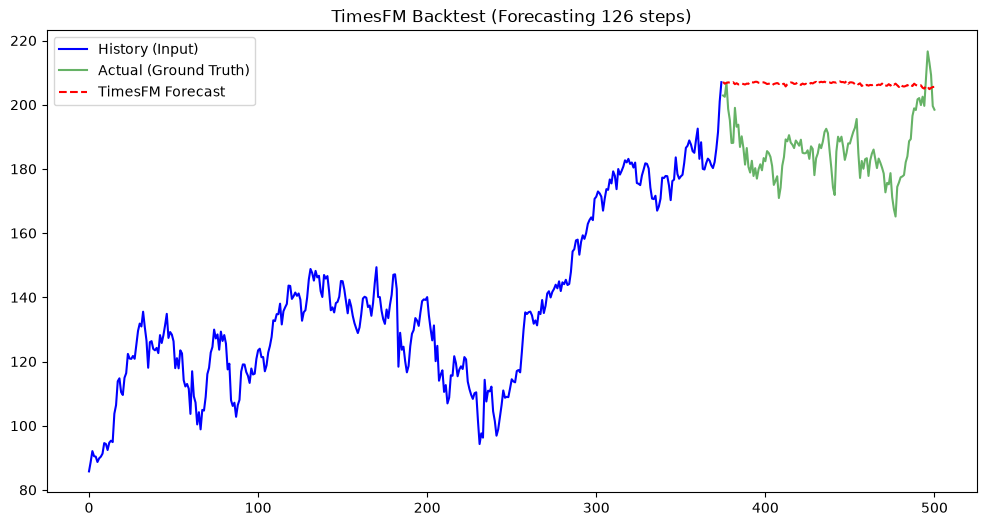

In [76]:
#Inference
with torch.no_grad():
    outputs = model(past_values=[prices_tensor], freq=torch.zeros(1, dtype=torch.long))

# 6. Denormalize Predictions
pred_norm = outputs.mean_predictions[0].cpu().numpy().flatten()
pred = (pred_norm * hist_std) + hist_mean

# 7. Plotting
plt.figure(figsize=(12, 6))
# Plot History
plt.plot(range(split_idx), history_data, label="History (Input)", color="blue")
# Plot Actual (Ground Truth)
plt.plot(range(split_idx, len(prices)), ground_truth, label="Actual (Ground Truth)", color="green", alpha=0.6)
# Plot Prediction (Limited to the length of our backtest window)
plt.plot(range(split_idx, split_idx + months_back), pred[:months_back], label="TimesFM Forecast", color="red", linestyle="--")

plt.title(f"TimesFM Backtest (Forecasting {months_back} steps)")
plt.legend()
plt.show()
